In [1]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import chi2

In [3]:
df = pd.read_csv("klachten.csv")

X = df["Omschrijving"].astype(str)
y = df["Product"].astype(str)

In [4]:
# tf idf 
tfidf = TfidfVectorizer(
    preprocessor=None,       # gebruik originele tekst
    tokenizer=None,
    stop_words="english",
    ngram_range=(1,2),       # unigrams + bigrams
    min_df=3,
    max_df=0.90
)

X_tfidf = tfidf.fit_transform(X)
feature_names = np.array(tfidf.get_feature_names_out())

In [7]:
#chi2
class_labels = sorted(y.unique())

top_words_per_class = {}

for cls in class_labels:
    # binaire target voor chi2
    y_binary = (y == cls).astype(int)

    # chi² test
    chi2_scores, p_values = chi2(X_tfidf, y_binary)

    # hoogste scores = meest onderscheidend
    top_indices = np.argsort(chi2_scores)[::-1]

    top_words = feature_names[top_indices][:50]  # pak de top 50
    top_words_per_class[cls] = top_words

    print(f"\nTop woorden voor {cls}")
    print(", ".join(top_words[:30]))


Top woorden voor Bankrekening
overdraft, bank, deposit, checking, checking account, branch, atm, funds, deposited, overdraft fees, transactions, debit, account, debit card, savings, check, money, savings account, deposits, overdraft fee, bank america, fees, direct deposit, transaction, overdrawn, america, banking, teller, account bank, promotion

Top woorden voor Consumentenkrediet
car, vehicle, dealership, dealer, auto, santander, auto loan, toyota, honda, ally, nissan, finance, loan, credit acceptance, ford, repossession, repossessed, car loan, lease, gm, financed, westlake, repo, drive time, chrysler, acceptance, vehicle xxxx, toyota financial, gm financial, car xxxx

Top woorden voor Creditcard
card, credit card, american express, amex, express, citi, discover, synchrony, rewards, synchrony bank, capital, american, macy, purchases, annual fee, cards, balance transfer, card account, balance, citibank, limit, card xxxx, card company, merchant, points, credit limit, barclay, minimum,

In [8]:
# extra overlap analyse 
from collections import defaultdict

# verzamel sets per klasse
word_sets = {cls: set(top_words_per_class[cls]) for cls in class_labels}

# overlap matrix
print("\nOverlap tussen klassen")
for cls1 in class_labels:
    for cls2 in class_labels:
        if cls1 != cls2:
            overlap = word_sets[cls1] & word_sets[cls2]
            if len(overlap) > 0:
                print(f"{cls1} ↔ {cls2}: {len(overlap)} overlappende woorden: {list(overlap)[:10]}")



Overlap tussen klassen
Bankrekening ↔ Creditcard: 3 overlappende woorden: ['fee', 'bonus', 'chase']
Bankrekening ↔ Incasso: 2 overlappende woorden: ['bank', 'chase']
Bankrekening ↔ Kredietregistratie: 1 overlappende woorden: ['bank']
Consumentenkrediet ↔ Creditcard: 1 overlappende woorden: ['loan']
Consumentenkrediet ↔ Hypotheek: 1 overlappende woorden: ['loan']
Consumentenkrediet ↔ Incasso: 1 overlappende woorden: ['loan']
Consumentenkrediet ↔ Kredietregistratie: 1 overlappende woorden: ['loan']
Creditcard ↔ Bankrekening: 3 overlappende woorden: ['fee', 'bonus', 'chase']
Creditcard ↔ Consumentenkrediet: 1 overlappende woorden: ['loan']
Creditcard ↔ Hypotheek: 3 overlappende woorden: ['card', 'loan', 'debt']
Creditcard ↔ Incasso: 5 overlappende woorden: ['chase', 'card', 'debt', 'late', 'loan']
Creditcard ↔ Kredietregistratie: 1 overlappende woorden: ['loan']
Hypotheek ↔ Consumentenkrediet: 1 overlappende woorden: ['loan']
Hypotheek ↔ Creditcard: 3 overlappende woorden: ['card', 'loan

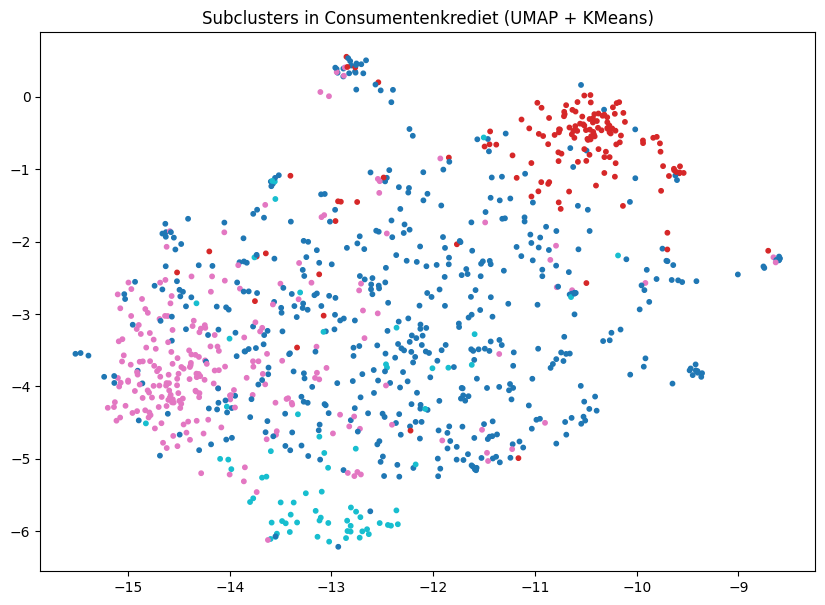

In [11]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import umap
import matplotlib.pyplot as plt

# Focus op één categorie eerst (Consumentenkrediet)
subset = df[df["Product"] == "Consumentenkrediet"]["Omschrijving"].astype(str)

tfidf = TfidfVectorizer(stop_words="english", ngram_range=(1,2), min_df=3, max_df=0.95)
X = tfidf.fit_transform(subset)

# Dimensionality reduction
embedding = umap.UMAP(n_neighbors=20, min_dist=0.1, metric="cosine").fit_transform(X)

# Clustering
k = 4   # aantal clusters dat je wil onderzoeken
km = KMeans(n_clusters=k, random_state=42).fit(X)
labels = km.labels_

plt.figure(figsize=(10,7))
plt.scatter(embedding[:,0], embedding[:,1], c=labels, cmap="tab10", s=10)
plt.title("Subclusters in Consumentenkrediet (UMAP + KMeans)")
plt.show()

In [12]:
for c in range(k):
    print(f"\nCluster {c}")
    examples = subset.iloc[labels == c].head(5).tolist()
    for ex in examples:
        print(" -", ex)


Cluster 0
 - I am XXXX years old and can not pay {$570.00} per month for this transaction I did not know that the usury interest of 223 % would be so much ... .They want me to pay {$10.00} XXXX in interest on a {$3000.00} my social security check is XXXX ... .Please help me
 - This loan went into default status off 5 years ago after I fell behind in payments. I attempted to reach out through their XXXXXXXXXXXX email and never got anything back. Eventually the loan was charged off but remained on my credit. In an attempt to repair my credit, I submitted several dispute claims to validate the loan and received nothing in return. Currently, my wife and I are trying to close on a new home loan, but conventional loans prohibit any disputes listed on your file. I tried to go through XXXX to have the verbiage removed to satisfy the requirement, but was told by them that we have to get Prospers approval. We called Prosper and was told that they will not approve the removal of the dispute verb

In [13]:
from collections import Counter

def top_words(texts, n=200):
    all_tokens = " ".join(texts).lower().split()
    freq = Counter(all_tokens)
    return set([w for w, _ in freq.most_common(n)])

classes = df["Product"].unique()
wordsets = {}

for cls in classes:
    subset = df[df["Product"] == cls]["Omschrijving"].astype(str)
    wordsets[cls] = top_words(subset)

print("\nJaccard similarity between categories")
for c1 in classes:
    for c2 in classes:
        if c1 != c2:
            j = len(wordsets[c1] & wordsets[c2]) / len(wordsets[c1] | wordsets[c2])
            print(f"{c1} ↔ {c2}: {j:.3f}")


Jaccard similarity between categories
Bankrekening ↔ Consumentenkrediet: 0.613
Bankrekening ↔ Creditcard: 0.695
Bankrekening ↔ Hypotheek: 0.613
Bankrekening ↔ Incasso: 0.550
Bankrekening ↔ Kredietregistratie: 0.471
Consumentenkrediet ↔ Bankrekening: 0.613
Consumentenkrediet ↔ Creditcard: 0.688
Consumentenkrediet ↔ Hypotheek: 0.717
Consumentenkrediet ↔ Incasso: 0.633
Consumentenkrediet ↔ Kredietregistratie: 0.527
Creditcard ↔ Bankrekening: 0.695
Creditcard ↔ Consumentenkrediet: 0.688
Creditcard ↔ Hypotheek: 0.646
Creditcard ↔ Incasso: 0.575
Creditcard ↔ Kredietregistratie: 0.504
Hypotheek ↔ Bankrekening: 0.613
Hypotheek ↔ Consumentenkrediet: 0.717
Hypotheek ↔ Creditcard: 0.646
Hypotheek ↔ Incasso: 0.606
Hypotheek ↔ Kredietregistratie: 0.515
Incasso ↔ Bankrekening: 0.550
Incasso ↔ Consumentenkrediet: 0.633
Incasso ↔ Creditcard: 0.575
Incasso ↔ Hypotheek: 0.606
Incasso ↔ Kredietregistratie: 0.646
Kredietregistratie ↔ Bankrekening: 0.471
Kredietregistratie ↔ Consumentenkrediet: 0.527
Kred

In [14]:
from sklearn.decomposition import LatentDirichletAllocation

lda = LatentDirichletAllocation(n_components=10, random_state=42)
lda.fit(X)

for i, topic in enumerate(lda.components_):
    top_indices = topic.argsort()[::-1][:15]
    words = tfidf.get_feature_names_out()[top_indices]
    print(f"\nTopic {i}")
    print(", ".join(words))


Topic 0
notarized, days past, monthly statement, delinquency, reviewed, phone work, references, suntrust, reviewed credit, thought monthly, shocked reviewed, statements thought, dates 30, happened believe, sure happened

Topic 1
legal, account reporting, paid agreed, deceptive, let, home equity, score xxxx, xx 2013, delinquency, personal loan, modification, late fees, credit reports, ran, inaccurate

Topic 2
nfcu, deferment, setting, auto pay, mbfs, xxxx 15, did process, public, volkswagen, stuck, equifax, xxxx needs, statute limitations, friendly, defective

Topic 3
xxxx, xxxx xxxx, xx, loan, credit, payment, 00, car, account, payments, xx xx, vehicle, pay, xx xxxx, company

Topic 4
td bank, td, late fees, consolidation, tila, citibank, rejected, account current, student loans, payment applied, client, settle debt, did apply, calling work, xxxx different

Topic 5
gm, theft, gm financial, chase auto, picture loans, big picture, picture, identity theft, overpayment, late fees, deficien